In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression



In [3]:
df = pd.read_csv("DataCoSupplyChainDataset.csv", encoding='latin1')
df.head(5)

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [4]:
df['Order State'].head(13)

0           Java Occidental
1                  Rajastán
2                  Rajastán
3                Queensland
4                Queensland
5                Queensland
6                 Guangdong
7                 Guangdong
8                 Guangdong
9                 Guangdong
10                    Tokio
11    Célebes Septentrional
12    Célebes Septentrional
Name: Order State, dtype: object

In [5]:
df.shape

(180519, 53)

In [6]:
df.columns  

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product De

In [7]:
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Price,Product Status
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180516.000000,180519.000000,180519.000000,...,180519.000000,180519.000000,180519.000000,180519.000000,24840.000000,180519.000000,180519.000000,0.0,180519.000000,180519.0
mean,3.497654,2.931847,21.974989,183.107609,0.548291,31.851451,6691.379495,35921.126914,5.443460,29.719955,...,2.127638,203.772096,183.107609,21.974989,55426.132327,692.509764,31.851451,NaN,141.232550,0.0
std,1.623722,1.374449,104.433526,120.043670,0.497664,15.640064,4162.918106,37542.461122,1.629246,9.813646,...,1.453451,132.273077,120.043670,104.433526,31919.279101,336.446807,15.640064,NaN,139.732492,0.0
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,2.000000,1.000000,603.000000,2.000000,-33.937553,...,1.000000,9.990000,7.490000,-4274.979980,1040.000000,19.000000,2.000000,NaN,9.990000,0.0
25%,2.000000,2.000000,7.000000,104.379997,0.000000,18.000000,3258.500000,725.000000,4.000000,18.265432,...,1.000000,119.980003,104.379997,7.000000,23464.000000,403.000000,18.000000,NaN,50.000000,0.0
50%,3.000000,4.000000,31.520000,163.990005,1.000000,29.000000,6457.000000,19380.000000,5.000000,33.144863,...,1.000000,199.919998,163.990005,31.520000,59405.000000,627.000000,29.000000,NaN,59.990002,0.0
75%,5.000000,4.000000,64.800003,247.399994,1.000000,45.000000,9779.000000,78207.000000,7.000000,39.279617,...,3.000000,299.950012,247.399994,64.800003,90008.000000,1004.000000,45.000000,NaN,199.990005,0.0
max,6.000000,4.000000,911.799988,1939.989990,1.000000,76.000000,20757.000000,99205.000000,12.000000,48.781933,...,5.000000,1999.989990,1939.989990,911.799988,99301.000000,1363.000000,76.000000,NaN,1999.989990,0.0


In [8]:
df.dtypes

Type                              object
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Delivery Status                   object
Late_delivery_risk                 int64
Category Id                        int64
Category Name                     object
Customer City                     object
Customer Country                  object
Customer Email                    object
Customer Fname                    object
Customer Id                        int64
Customer Lname                    object
Customer Password                 object
Customer Segment                  object
Customer State                    object
Customer Street                   object
Customer Zipcode                 float64
Department Id                      int64
Department Name                   object
Latitude                         float64
Longitude                        float64
Market          

In [9]:
df.isnull().sum()

Type                                  0
Days for shipping (real)              0
Days for shipment (scheduled)         0
Benefit per order                     0
Sales per customer                    0
Delivery Status                       0
Late_delivery_risk                    0
Category Id                           0
Category Name                         0
Customer City                         0
Customer Country                      0
Customer Email                        0
Customer Fname                        0
Customer Id                           0
Customer Lname                        8
Customer Password                     0
Customer Segment                      0
Customer State                        0
Customer Street                       0
Customer Zipcode                      3
Department Id                         0
Department Name                       0
Latitude                              0
Longitude                             0
Market                                0


In [10]:
df['Customer Zipcode'].value_counts().head()

Customer Zipcode
725.0      66770
921.0        337
23455.0      334
957.0        297
79109.0      292
Name: count, dtype: int64

In [11]:
df['Customer Zipcode'] = df['Customer Zipcode'].fillna(df['Customer Zipcode'].mode()[0])


In [12]:
df['Customer Zipcode'].isnull().sum()

np.int64(0)

In [13]:
df.drop('Order Zipcode',axis=1,inplace=True)

In [14]:
df.drop('Product Description',axis=1,inplace=True)

In [15]:
df.shape

(180519, 51)

In [16]:
# change datatype
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
df['shipping date (DateOrders)'] = pd.to_datetime(df['shipping date (DateOrders)'])

In [17]:
# Delivery time
df['Delivery Time'] = (df['shipping date (DateOrders)'] - df['order date (DateOrders)']).dt.days

# Order month
df['Order Month'] = df['order date (DateOrders)'].dt.month

# Order year
df['Order Year'] = df['order date (DateOrders)'].dt.year


In [18]:
df.head(2)

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Product Category Id,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode,Delivery Time,Order Month,Order Year
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-02-03 22:56:00,Standard Class,3,1,2018
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-18 12:27:00,Standard Class,5,1,2018


In [19]:
cols_to_clean = df[['Order City', 'Order State', 'Order Country','Order Region']]

In [20]:
import unicodedata
import re  
def clean_text(text):
    if isinstance(text, str):
        # remove accents
        text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8')
        # remove special characters
        text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
        # remove extra spaces + standardize
        text = text.strip().lower()
    return text

for col in cols_to_clean:
    df[col] = df[col].apply(clean_text)

In [21]:
df['Order Country'].head(20)

0         indonesia
1             india
2             india
3         australia
4         australia
5         australia
6             china
7             china
8             china
9             china
10            japon
11        indonesia
12        indonesia
13            india
14            india
15            india
16    corea del sur
17            india
18            india
19            india
Name: Order Country, dtype: object

In [22]:
df['Order Region'].value_counts()

Order Region
central america    28341
western europe     27109
south america      14935
oceania            10148
northern europe     9792
southeast asia      9539
southern europe     9431
caribbean           8318
west of usa         7993
south asia          7731
eastern asia        7280
east of usa         6915
west asia           6009
us center           5887
south of  usa       4045
eastern europe      3920
west africa         3696
north africa        3232
east africa         1852
central africa      1677
southern africa     1157
canada               959
central asia         553
Name: count, dtype: int64

In [23]:
df['Product Name'].value_counts()

Product Name
Perfect Fitness Perfect Rip Deck                 24515
Nike Men's CJ Elite 2 TD Football Cleat          22246
Nike Men's Dri-FIT Victory Golf Polo             21035
O'Brien Men's Neoprene Life Vest                 19298
Field & Stream Sportsman 16 Gun Fire Safe        17325
                                                 ...  
Stiga Master Series ST3100 Competition Indoor       27
SOLE E35 Elliptical                                 15
Bushnell Pro X7 Jolt Slope Rangefinder              11
SOLE E25 Elliptical                                 10
Bowflex SelectTech 1090 Dumbbells                   10
Name: count, Length: 118, dtype: int64

In [24]:
df['Category Name'].value_counts()

Category Name
Cleats                  24551
Men's Footwear          22246
Women's Apparel         21035
Indoor/Outdoor Games    19298
Fishing                 17325
Water Sports            15540
Camping & Hiking        13729
Cardio Equipment        12487
Shop By Sport           10984
Electronics              3156
Accessories              1780
Golf Balls               1475
Girls' Apparel           1201
Golf Gloves              1070
Trade-In                  974
Video Games               838
Children's Clothing       652
Women's Clothing          650
Baseball & Softball       632
Hockey                    614
Cameras                   592
Toys                      529
Golf Shoes                524
Pet Supplies              492
Crafts                    484
Garden                    484
DVDs                      483
Computers                 442
Golf Apparel              441
Hunting & Shooting        440
Music                     434
Consumer Electronics      431
Boxing & MMA              

In [25]:
df.groupby('Category Name')['Sales per customer'].sum()

Category Name
Accessories             1.197125e+05
As Seen on  TV!         1.851961e+04
Baby                    1.095740e+04
Baseball & Softball     8.436727e+04
Basketball              2.470533e+04
Books                   1.130342e+04
Boxing & MMA            7.628672e+04
CDs                     2.750030e+03
Cameras                 2.404967e+05
Camping & Hiking        3.700784e+06
Cardio Equipment        3.320251e+06
Children's Clothing     2.092684e+05
Cleats                  3.982857e+06
Computers               5.953950e+05
Consumer Electronics    9.793756e+04
Crafts                  2.007049e+05
DVDs                    7.131938e+04
Electronics             3.333273e+05
Fishing                 6.226935e+06
Fitness Accessories     3.175136e+04
Garden                  2.317655e+05
Girls' Apparel          1.362068e+05
Golf Apparel            3.144744e+04
Golf Bags & Carts       9.403790e+03
Golf Balls              6.934125e+04
Golf Gloves             1.047874e+05
Golf Shoes              

In [26]:
df.groupby('Product Name')['Sales per customer'].sum()

Product Name
Adult dog supplies                               37318.299847
Baby sweater                                     10957.400143
Bag Boy Beverage Holder                          19009.969910
Bag Boy M330 Push Cart                           14981.660008
Bowflex SelectTech 1090 Dumbbells                 5171.899902
                                                     ...     
adidas Kids' F5 Messi FG Soccer Cleat            24626.510213
adidas Men's F10 Messi TRX FG Soccer Cleat       50354.210668
adidas Men's Germany Black Crest Away Tee        19279.919983
adidas Youth Germany Black/Red Away Match Soc    61037.900009
insta-bed Neverflat Air Mattress                  8011.650148
Name: Sales per customer, Length: 118, dtype: float64

In [27]:
df.groupby('Customer City')['Sales'].sum()

Customer City
Aguadilla       10851.130284
Alameda         23868.440453
Albany          15813.450201
Albuquerque    115059.892229
Algonquin       26871.300533
                   ...      
Yonkers         26672.520535
York            48201.350899
Ypsilanti       29787.890532
Yuma            19060.410441
Zanesville      23663.250457
Name: Sales, Length: 563, dtype: float64

In [28]:
df.groupby('Order Year')['Sales'].sum()

Order Year
2015    1.234083e+07
2016    1.230382e+07
2017    1.180844e+07
2018    3.316501e+05
Name: Sales, dtype: float64

In [29]:
df[['Order Item Product Price','Product Price','Sales']].tail(10)

,Order Item Product Price,Product Price,Sales
180509,399.980011,399.980011,399.980011
180510,399.980011,399.980011,399.980011
180511,399.980011,399.980011,399.980011
180512,399.980011,399.980011,399.980011
180513,399.980011,399.980011,399.980011
180514,399.980011,399.980011,399.980011
180515,399.980011,399.980011,399.980011
180516,399.980011,399.980011,399.980011
180517,399.980011,399.980011,399.980011
180518,399.980011,399.980011,399.980011


In [30]:
(df['Order Item Product Price']==df['Product Price']).all()

np.True_

In [31]:
(df['Product Price']==df['Sales']).all()

np.False_

In [32]:
df.drop('Order Item Product Price',axis=1,inplace=True)

In [33]:
df[['Order Profit Per Order','Benefit per order']]

,Order Profit Per Order,Benefit per order
0,91.250000,91.250000
1,-249.089996,-249.089996
2,-247.779999,-247.779999
3,22.860001,22.860001
4,134.210007,134.210007
...,...,...
180514,40.000000,40.000000
180515,-613.770019,-613.770019
180516,141.110001,141.110001
180517,186.229996,186.229996


In [34]:
(df['Order Profit Per Order']==df['Benefit per order']).all()

np.True_

In [35]:
df.drop('Benefit per order',axis=1,inplace=True)

In [36]:
(df['Sales per customer']==df['Sales']).all()

np.False_

In [37]:
#useless column
df.drop(['Customer Email',
         'Customer Fname',
         'Customer Lname',
         'Customer Password',
         'Customer Street'],axis=1,inplace=True)

In [38]:
#irrelevent columns
df.drop(['Order Id',
         'Customer Id',
         'Product Card Id',
         'Order Customer Id',
         'Order Item Id',
         'Product Image',
         'Order Item Cardprod Id'],axis=1,inplace=True)

In [39]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Sales per customer', 'Delivery Status', 'Late_delivery_risk',
       'Category Id', 'Category Name', 'Customer City', 'Customer Country',
       'Customer Segment', 'Customer State', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'order date (DateOrders)',
       'Order Item Discount', 'Order Item Discount Rate',
       'Order Item Profit Ratio', 'Order Item Quantity', 'Sales',
       'Order Item Total', 'Order Profit Per Order', 'Order Region',
       'Order State', 'Order Status', 'Product Category Id', 'Product Name',
       'Product Price', 'Product Status', 'shipping date (DateOrders)',
       'Shipping Mode', 'Delivery Time', 'Order Month', 'Order Year'],
      dtype='object')

In [40]:
df['Order Item Quantity'].value_counts()

Order Item Quantity
1    99134
5    20385
3    20350
4    20335
2    20315
Name: count, dtype: int64

In [41]:
df['Department Name'].nunique()

11

In [42]:
df.shape

(180519, 40)

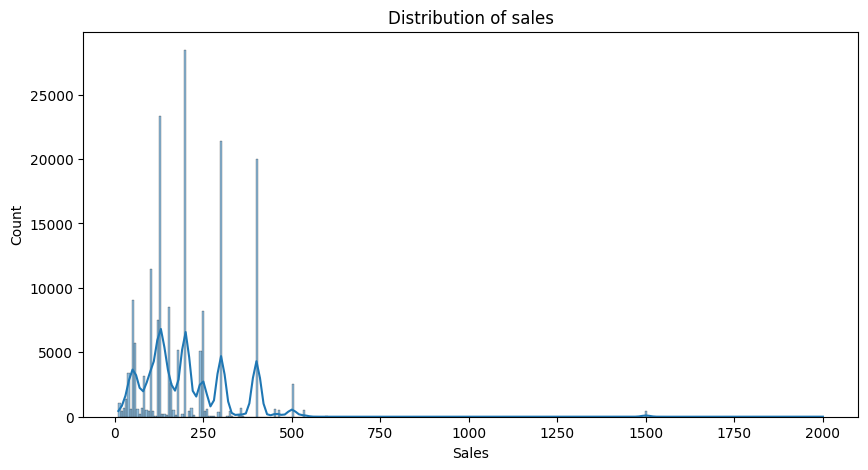

In [43]:
plt.figure(figsize=(10,5))
sns.histplot(df['Sales'],kde=True)
plt.title('Distribution of sales')
plt.show()

In [44]:

df["Sales_log"] = np.log(df["Sales"])

In [45]:
df["Sales"].skew()

np.float64(2.884249048729941)

In [46]:
df["Sales_log"].skew()

np.float64(-0.7069479055401657)

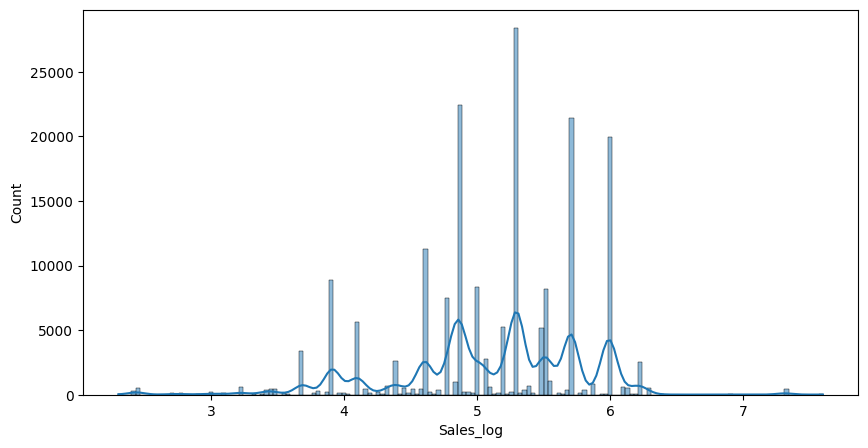

In [47]:
plt.figure(figsize=(10,5))
sns.histplot(df["Sales_log"], kde=True)
plt.show()

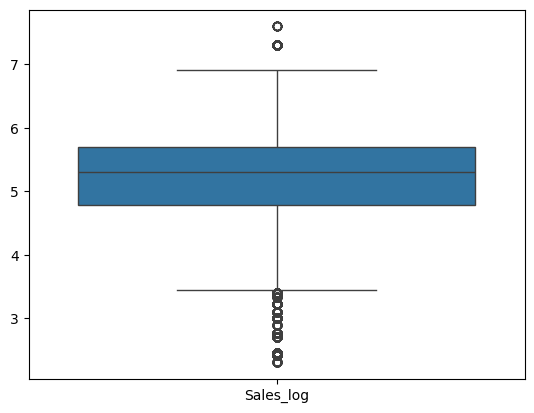

In [48]:
sns.boxplot(data=df[['Sales_log']])
plt.show()

In [49]:
Top_cities = df['Customer City'].value_counts().head(10)
print(Top_cities)

Customer City
Caguas          66770
Chicago          3885
Los Angeles      3417
Brooklyn         3412
New York         1816
Philadelphia     1577
Bronx            1500
San Diego        1437
Miami            1314
Houston          1297
Name: count, dtype: int64


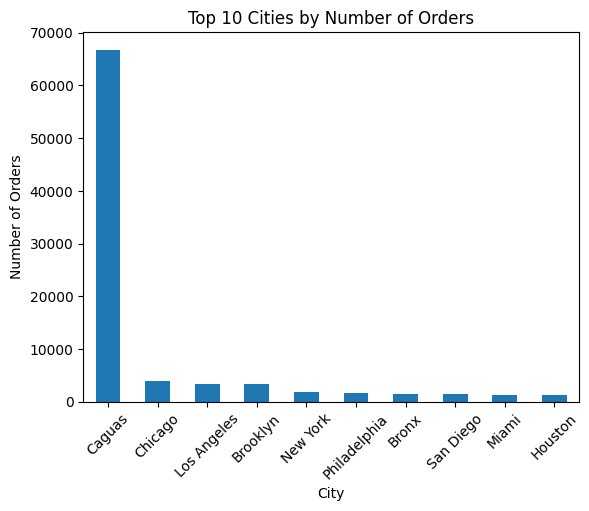

In [50]:
 
Top_cities.plot(kind='bar')
plt.title("Top 10 Cities by Number of Orders")
plt.xlabel("City")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

In [51]:
Delay = df.groupby('Shipping Mode')['Late_delivery_risk'].sum()
print(Delay)

Shipping Mode
First Class       26513
Same Day           4454
Second Class      26987
Standard Class    41023
Name: Late_delivery_risk, dtype: int64


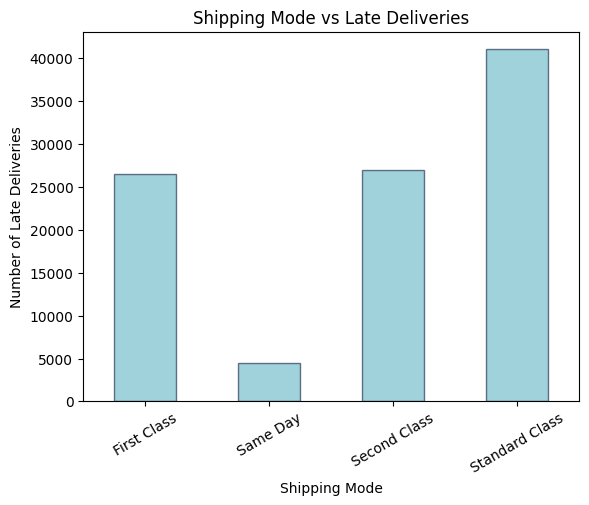

In [52]:
Delay.plot(kind='bar',color="#0C8DA364",edgecolor="#030F3690")
 
plt.title("Shipping Mode vs Late Deliveries")
plt.xlabel("Shipping Mode")
plt.ylabel("Number of Late Deliveries")

plt.xticks(rotation=30)
plt.show()

In [53]:
df.shape

(180519, 41)

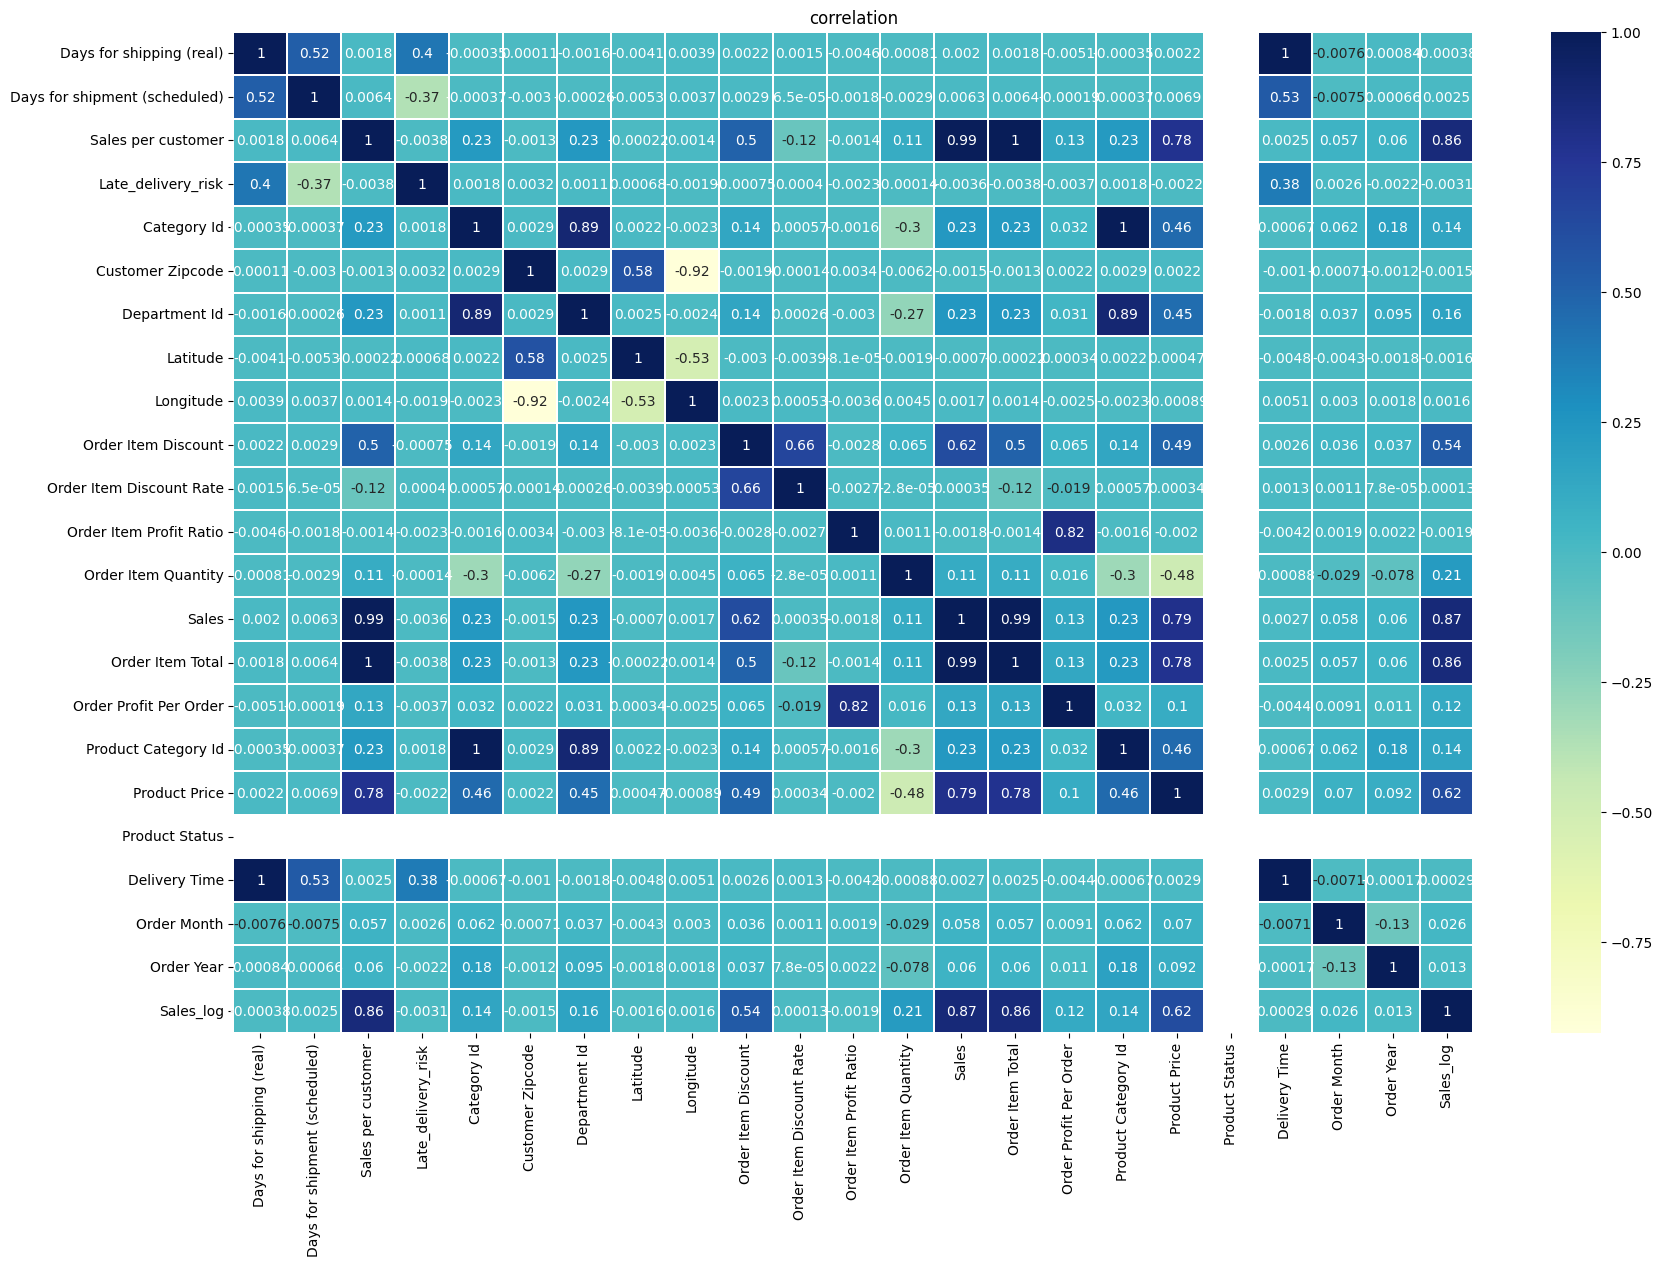

In [54]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(20,13))
sns.heatmap(corr, annot=True, cmap = 'YlGnBu',linewidths=0.3)
plt.title('correlation')
plt.show()

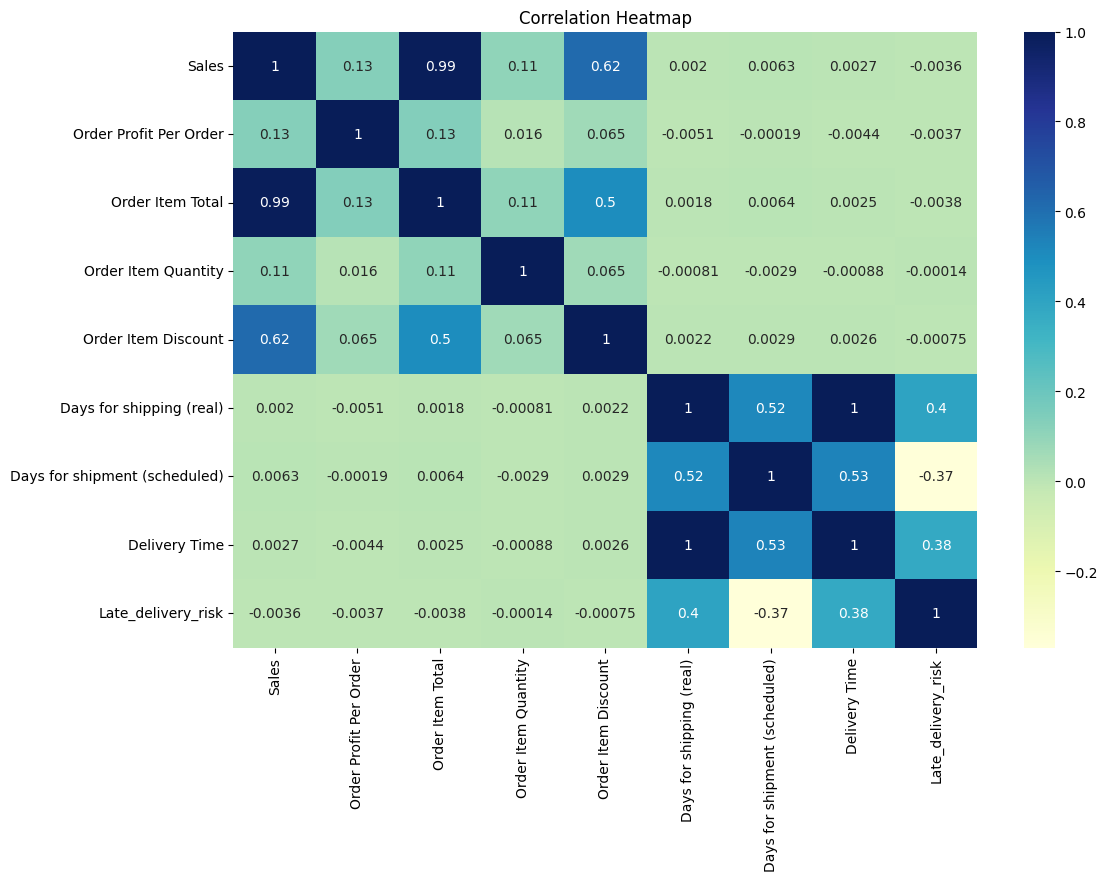

In [55]:
selected_cols = [
    'Sales',
    'Order Profit Per Order',
    'Order Item Total',
    'Order Item Quantity',
    'Order Item Discount',
    'Days for shipping (real)',
    'Days for shipment (scheduled)',
    'Delivery Time',
    'Late_delivery_risk'
]

corr = df[selected_cols].corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='YlGnBu')
plt.title("Correlation Heatmap")
plt.show()

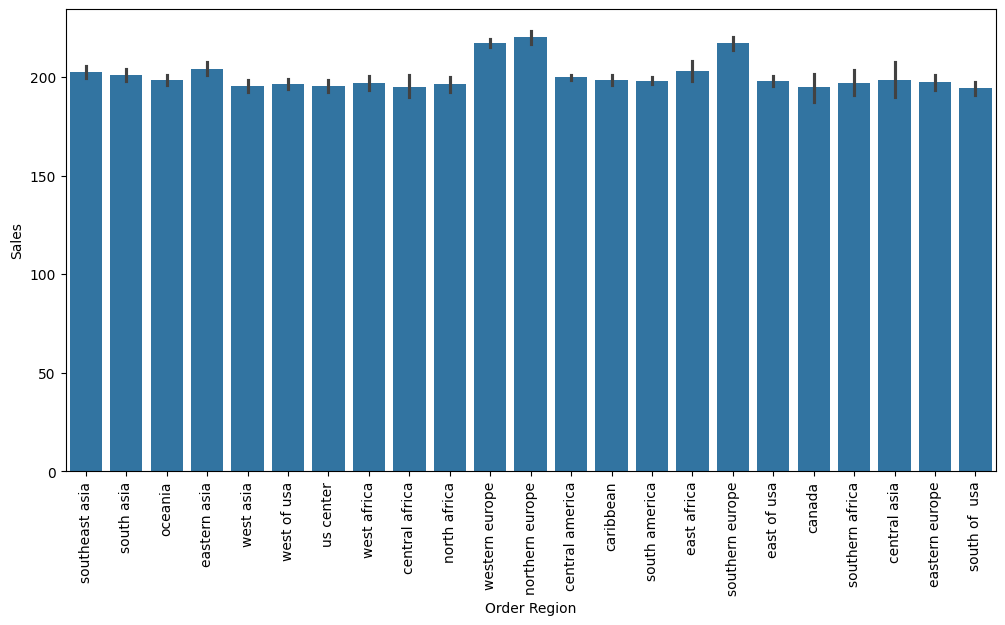

In [56]:
plt.figure(figsize=(12,6))
sns.barplot(x='Order Region', y='Sales', data=df)
plt.xticks(rotation=90)
plt.show()

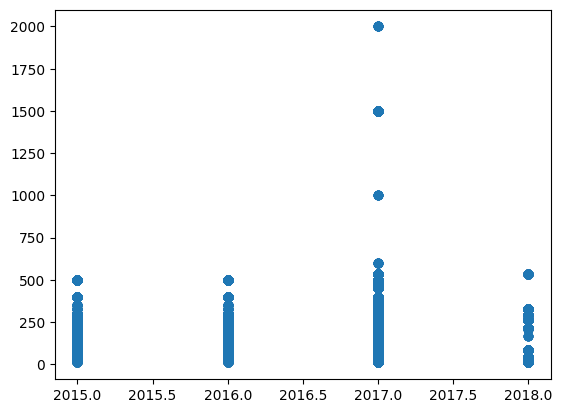

In [57]:
plt.scatter(df['Order Year'],df['Sales'])
plt.show()

In [58]:
df.drop(['Delivery Status',
         'Sales', 
         'Order Item Total',
         'Order Item Profit Ratio',
         'Customer City', 'Customer State',
         'Order City','Order State',
         'Category Id',
         'Department Id',
         'Product Category Id',
         'shipping date (DateOrders)',
         'order date (DateOrders)',
         'Order Status',
         'Late_delivery_risk',
         'Days for shipping (real)',
         'Order Item Discount',
         'Latitude',
         'Longitude',
         'Sales per customer',
         'Order Profit Per Order',
         'Type',
         'Department Name',
         'Product Name',
         'Customer Country',
         'Customer Zipcode',
         'Order Country',
         'Order Region',
         'Product Status',



],axis= 1,inplace=True)

In [59]:
df.shape

(180519, 12)

In [60]:
df.columns

Index(['Days for shipment (scheduled)', 'Category Name', 'Customer Segment',
       'Market', 'Order Item Discount Rate', 'Order Item Quantity',
       'Product Price', 'Shipping Mode', 'Delivery Time', 'Order Month',
       'Order Year', 'Sales_log'],
      dtype='object')

In [61]:
df = pd.get_dummies(df, drop_first=True)

In [62]:
X = df.drop(['Sales_log'], axis=1)
y = df['Sales_log']

In [63]:
y.dtype 

dtype('float64')

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [65]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [66]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [67]:
y_pred_log = model.predict(X_test)

In [68]:
from sklearn.metrics import r2_score

print("R2 (log):", r2_score(y_test, y_pred_log))

R2 (log): 0.9526261157962286


In [69]:
import numpy as np

y_pred = np.exp(y_pred_log)
y_test_actual = np.exp(y_test)

In [70]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
r2 = r2_score(y_test_actual, y_pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 5219.762420577367
R2: -1570.1895710310937


## Why R² negative after inverse?



#### Because the model was trained on log-transformed target. When converting back using exponential, small prediction errors get amplified, which affects R² on original scale. Therefore, evaluation is done on log scale where assumptions hold.

In [71]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5, scoring='r2')

print("CV R2:", scores)
print("Mean CV R2:", scores.mean())

CV R2: [0.88485867 0.87972955 0.9545482  0.9641168  0.96137645]
Mean CV R2: 0.9289259318497557


In [72]:
print(r2_score(y_test, y_pred_log))

0.9526261157962286


#### - Model performance is evaluated on log-transformed target due to skewness in Sales.

In [73]:
import pandas as pd

comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_log
})

print(comparison.head(10))

          Actual  Predicted
80120   5.298267   5.291308
19670   5.521461   5.655462
114887  5.521061   5.632372
120110  5.703716   5.700471
56658   4.787242   4.657346
99465   5.297917   5.252293
40749   5.991415   5.989569
22688   5.703682   5.535790
154389  4.605170   4.492081
47301   4.787242   4.654886


In [74]:
comparison = pd.DataFrame({
    "Actual": np.exp(y_test),
    "Predicted": np.exp(y_pred_log)
})

In [75]:
residuals = y_test - y_pred_log

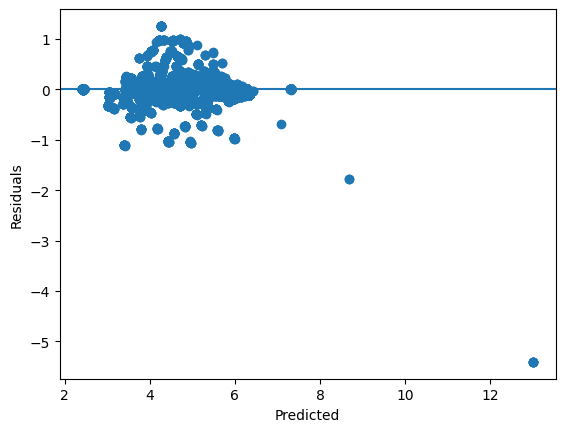

In [76]:
import matplotlib.pyplot as plt

plt.scatter(y_pred_log, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()

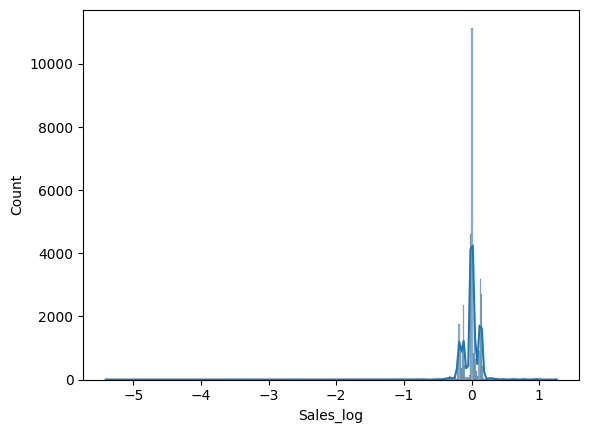

In [77]:
import seaborn as sns

sns.histplot(residuals, kde=True)
plt.show()

In [78]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred_log)
print("MAE:", mae)

MAE: 0.0837157112251926


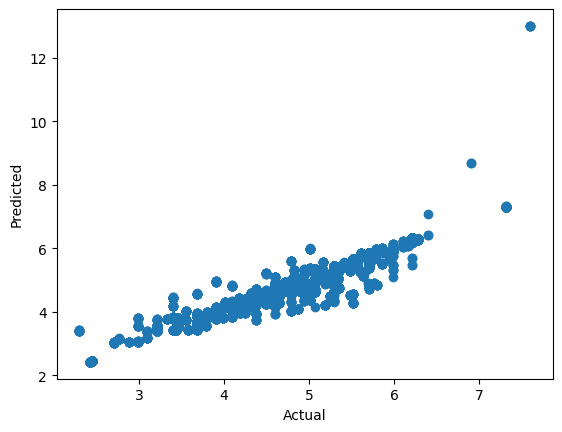

In [79]:
plt.scatter(y_test, y_pred_log)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

In [80]:
df.shape

(180519, 66)

##  Data Loading

In this step, the supply chain dataset is loaded into a Pandas DataFrame for further analysis.  
Initial inspection is performed to understand the structure, number of rows, and available features.

This helps in identifying:
- Data types of each column  
- Presence of missing values  
- Overall dataset shape  

##  Data Understanding

Basic exploration is performed using functions like `.head()`, `.info()`, and `.describe()`.

Key observations:
- Identified numerical and categorical features  
- Checked for null values and inconsistent data types  
- Understood statistical distribution of numerical columns  

This step is important before applying any preprocessing or modeling.

##  Data Cleaning

Data cleaning is performed to improve data quality and ensure reliable model performance.

Steps included:
- Handling missing values  
- Fixing incorrect or inconsistent data types  
- Removing duplicates (if any)  

Clean data is essential for building an accurate machine learning model.

##  Categorical Encoding

Categorical variables are converted into numerical format using encoding techniques.

Approach used:
-  Label Encoding (based on data type)

This step is necessary because machine learning models cannot directly process categorical data.

##  Feature Selection

Relevant features are selected based on:
- Correlation with target variable  
- Business understanding  

Irrelevant or redundant features are removed to:
- Improve model performance  
- Reduce overfitting  

##  Train-Test Split

The dataset is divided into training and testing sets.

- Training data is used to train the model  
- Testing data is used to evaluate performance  

This ensures that the model generalizes well to unseen data.

##  Model Building - Linear Regression

A Linear Regression model is implemented to predict the target variable (sales/profit).

Why Linear Regression?
- Simple and interpretable  
- Works well for continuous target variables  

The model learns the relationship between input features and the target variable.

##  Model Evaluation

The model is evaluated using performance metrics:

- R² Score: Measures how well the model explains variance  
- Cross-validation: Ensures model stability  

Results indicate that the model performs well on both training and testing data.

##  Conclusion

The project successfully demonstrates an end-to-end machine learning workflow on a supply chain dataset.

Key outcomes:
- Built a predictive model for sales 
- Gained insights from data analysis  
- Achieved strong model performance  

This project highlights the importance of data preprocessing, feature selection, and proper evaluation techniques.